In [1]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [5]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("boston_housing.csv")

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [7]:
#Step 3: Split Features and Target
X = df.drop("price", axis=1)   # Features
y = df["price"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [8]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 610.1076 - mae: 22.8491 - val_loss: 537.2848 - val_mae: 21.7485
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 608.6402 - mae: 22.8365 - val_loss: 537.1614 - val_mae: 21.7507
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 607.2086 - mae: 22.8245 - val_loss: 537.0480 - val_mae: 21.7527
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 605.7437 - mae: 22.8109 - val_loss: 536.9130 - val_mae: 21.7538
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 604.2828 - mae: 22.7962 - val_loss: 536.7507 - val_mae: 21.7540
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 602.9844 - mae: 22.7848 - val_loss: 536.6616 - val_mae: 21.7561
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 601.6642 - mae: 22.7729 - val_loss: 536.5489 - val_mae: 21.7573
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 600.2717 - mae: 22.7599 - val_loss: 536.4020 - val_mae: 21.7575
Epoch 9/100
12/12 ━━

In [11]:
#Step 6: Build Deep Neural Network
model = Sequential()

# Single neuron → behaves like linear regression
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 625.6431 - mae: 22.9727 - val_loss: 558.0349 - val_mae: 22.0402
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 623.0856 - mae: 22.9524 - val_loss: 556.2759 - val_mae: 22.0240
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 620.5998 - mae: 22.9284 - val_loss: 554.4700 - val_mae: 22.0085
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 618.1419 - mae: 22.9083 - val_loss: 552.6962 - val_mae: 21.9928
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 615.7090 - mae: 22.8855 - val_loss: 550.9777 - val_mae: 21.9768
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 613.2260 - mae: 22.8610 - val_loss: 549.2256 - val_mae: 21.9608
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 610.8182 - mae: 22.8412 - val_loss: 547.5482 - val_mae: 21.9449
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 608.5184 - mae: 22.8193 - val_loss: 545.8378 - val_mae: 21.9297
Epoch 9/100
2

In [13]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 445.1410 - mae: 20.3065
Test Loss (MSE): 445.1410217285156
Test MAE: 20.306543350219727


In [14]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Actual: 23.60 | Predicted: 4.89
Actual: 32.40 | Predicted: 10.64
Actual: 13.60 | Predicted: -3.32
Actual: 22.80 | Predicted: 3.95
Actual: 16.10 | Predicted: -3.12


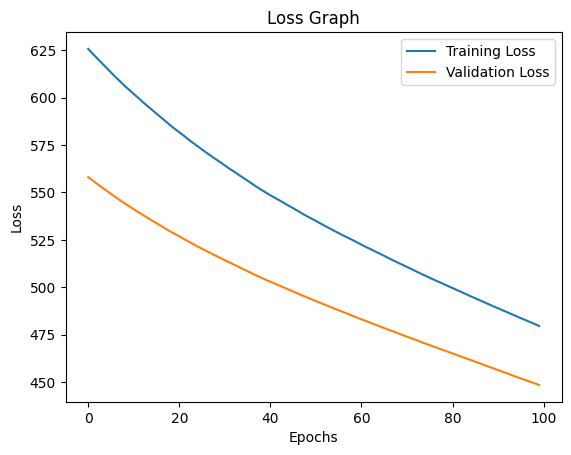

In [15]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()